<a href="https://colab.research.google.com/github/Zeynepsudeee/Zzeynepsudekus.github.io/blob/main/transfer_learning_son.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ml_dataset.zip to ml_dataset.zip


In [ ]:
import zipfile

zip_path = "ml_dataset.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
!pip install torch torchvision opencv-python scikit-learn matplotlib tqdm

In [ ]:
import os
import cv2
import random
import torch
import numpy as np

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
REAL_DIR = "/content/ml_dataset/real"
FAKE_DIR = "/content/ml_dataset/fake"

print("Real:", len(os.listdir(REAL_DIR)))
print("Fake:", len(os.listdir(FAKE_DIR)))

Real: 500
Fake: 500


In [ ]:
def get_common_ids(real_dir, fake_dir):
    real_ids = {
        os.path.splitext(f)[0]
        for f in os.listdir(real_dir)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    }
    fake_ids = {
        os.path.splitext(f)[0]
        for f in os.listdir(fake_dir)
        if f.lower().endswith(('.jpg', '.png', '.jpeg'))
    }
    return sorted(list(real_ids.intersection(fake_ids)))

ids = get_common_ids(REAL_DIR, FAKE_DIR)
print("Toplam ortak ID:", len(ids))

Toplam ortak ID: 497


In [ ]:
train_ids, temp_ids = train_test_split(
    ids, test_size=0.3, random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.5, random_state=42
)

print(
    f"Train: {len(train_ids)} | "
    f"Val: {len(val_ids)} | "
    f"Test: {len(test_ids)}"
)

Train: 347 | Val: 75 | Test: 75


In [ ]:
def find_image_path(base_dir, id_):
    for ext in ['.jpg', '.png', '.jpeg']:
        path = os.path.join(base_dir, id_ + ext)
        if os.path.exists(path):
            return path
    return None

In [ ]:
IMG_SIZE = 224

class SiameseDataset(Dataset):
    def __init__(self, id_list):
        self.id_list = id_list

    def __len__(self):
        return len(self.id_list)

    def load_image(self, path):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape
        crop = min(h, w)
        y = random.randint(0, h - crop)
        x = random.randint(0, w - crop)
        img = img[y:y+crop, x:x+crop]

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        img = torch.tensor(img).permute(2, 0, 1).float()
        return img

    def __getitem__(self, idx):
        id1 = self.id_list[idx]

        if random.random() < 0.5:
            id2 = id1
            label = 0.0
        else:
            id2 = random.choice(self.id_list)
            while id2 == id1:
                id2 = random.choice(self.id_list)
            label = 1.0

        img1_path = find_image_path(
            REAL_DIR if random.random() < 0.5 else FAKE_DIR, id1
        )
        img2_path = find_image_path(
            REAL_DIR if random.random() < 0.5 else FAKE_DIR, id2
        )

        if img1_path is None or img2_path is None:
            return self.__getitem__(random.randint(0, len(self.id_list) - 1))

        img1 = self.load_image(img1_path)
        img2 = self.load_image(img2_path)

        return img1, img2, torch.tensor(label)


In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    SiameseDataset(train_ids),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    SiameseDataset(val_ids),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    SiameseDataset(test_ids),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
import torch.nn as nn
from torchvision import models

class SiameseNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.vgg19(pretrained=True).features

        for p in self.backbone.parameters():
            p.requires_grad = False

        self.fc = nn.Sequential(
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 128)
        )

    def forward_once(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        return out1, out2


model = SiameseNetwork().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 122MB/s] 


In [ ]:
class ContrastiveLoss(nn.Module):
    def _init_(self, margin=1.0):
        super()._init_()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = (1 - label) * dist.pow(2) + \
               label * torch.clamp(self.margin - dist, min=0).pow(2)
        return loss.mean()

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = (1 - label) * dist.pow(2) + \
               label * torch.clamp(self.margin - dist, min=0).pow(2)
        return loss.mean()


In [ ]:
criterion = ContrastiveLoss(margin=1.0)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for img1, img2, labels in tqdm(loader):
        img1 = img1.to(device)
        img2 = img2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        out1, out2 = model(img1, img2)
        loss = criterion(out1, out2, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, threshold=0.5):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for img1, img2, labels in loader:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.to(device)

            out1, out2 = model(img1, img2)
            dist = F.pairwise_distance(out1, out2)
            preds = (dist > threshold).float()

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [ ]:
EPOCHS = 20

for epoch in range(EPOCHS):
    loss = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

100%|██████████| 22/22 [00:17<00:00,  1.25it/s]


Epoch [1/20] | Loss: 0.4441 | Val Acc: 0.7333


100%|██████████| 22/22 [00:16<00:00,  1.33it/s]


Epoch [2/20] | Loss: 0.2326 | Val Acc: 0.8800


100%|██████████| 22/22 [00:18<00:00,  1.22it/s]


...

Epoch [18/20] | Loss: 0.0538 | Val Acc: 0.8933


100%|██████████| 22/22 [00:16<00:00,  1.37it/s]


Epoch [19/20] | Loss: 0.0512 | Val Acc: 0.8800


100%|██████████| 22/22 [00:15<00:00,  1.38it/s]


Epoch [20/20] | Loss: 0.0519 | Val Acc: 0.9067


In [ ]:
for p in model.backbone[-8:].parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

EPOCHS_FINE = 10

for epoch in range(EPOCHS_FINE):
    loss = train_one_epoch(model, train_loader)
    val_acc = evaluate(model, val_loader)

    print(
        f"[Fine] Epoch [{epoch+1}/{EPOCHS_FINE}] | "
        f"Loss: {loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

100%|██████████| 22/22 [00:17<00:00,  1.27it/s]


[Fine] Epoch [1/10] | Loss: 0.0464 | Val Acc: 0.8933


100%|██████████| 22/22 [00:21<00:00,  1.03it/s]


[Fine] Epoch [2/10] | Loss: 0.0424 | Val Acc: 0.9333


100%|██████████| 22/22 [00:16<00:00,  1.30it/s]


...

[Fine] Epoch [8/10] | Loss: 0.0285 | Val Acc: 0.9733


100%|██████████| 22/22 [00:17<00:00,  1.28it/s]


[Fine] Epoch [9/10] | Loss: 0.0337 | Val Acc: 0.8533


100%|██████████| 22/22 [00:18<00:00,  1.17it/s]


[Fine] Epoch [10/10] | Loss: 0.0427 | Val Acc: 0.9200


In [ ]:
model.eval()

val_distances = []
val_labels = []

with torch.no_grad():
    for img1, img2, label in val_loader:
        img1, img2 = img1.to(device), img2.to(device)

        out1, out2 = model(img1, img2)
        dist = F.pairwise_distance(out1, out2)

        val_distances.extend(dist.cpu().numpy())
        val_labels.extend(label.cpu().numpy())

val_distances = np.array(val_distances)
val_labels = np.array(val_labels)


In [ ]:
from sklearn.metrics import f1_score


In [ ]:
thresholds = np.arange(0.1, 5.0, 0.01)
f1_scores = []

for t in thresholds:
    preds = (val_distances > t).astype(int)
    f1_scores.append(f1_score(val_labels, preds))

best_threshold = thresholds[np.argmax(f1_scores)]
print(" Seçilen threshold:", best_threshold)


 Seçilen threshold: 0.48999999999999977


In [ ]:
model.eval()

all_distances = []
all_labels = []

with torch.no_grad():
    for img1, img2, label in test_loader:
        img1, img2 = img1.to(device), img2.to(device)

        out1, out2 = model(img1, img2)
        dist = F.pairwise_distance(out1, out2)

        all_distances.extend(dist.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

all_distances = np.array(all_distances)
all_labels = np.array(all_labels)


In [ ]:
all_preds = (all_distances > best_threshold).astype(int)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


In [ ]:
print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall   :", recall_score(all_labels, all_preds))
print("F1-score :", f1_score(all_labels, all_preds))

print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))


Accuracy : 0.9466666666666667
Precision: 0.9428571428571428
Recall   : 0.9428571428571428
F1-score : 0.9428571428571428
Confusion Matrix:
 [[38  2]
 [ 2 33]]


In [ ]:
torch.save(model.state_dict(), "/content/vgg19_real_fake.pth")

In [ ]:
from google.colab import files
files.download("/content/vgg19_real_fake.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)


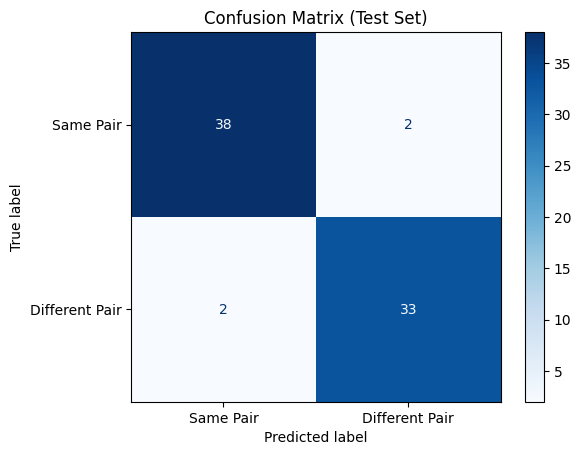

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Same Pair", "Different Pair"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()


In [ ]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 0.9467
Precision : 0.9429
Recall    : 0.9429
F1-score  : 0.9429


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

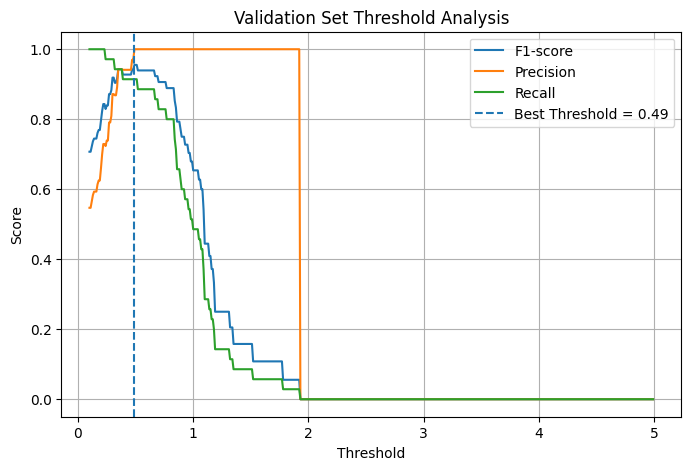

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 5.0, 0.01)

f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    preds = (val_distances > t).astype(int)
    f1_scores.append(f1_score(val_labels, preds))
    precisions.append(precision_score(val_labels, preds))
    recalls.append(recall_score(val_labels, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, label="F1-score")
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")

plt.axvline(best_threshold, linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Set Threshold Analysis")
plt.legend()
plt.grid()
plt.show()


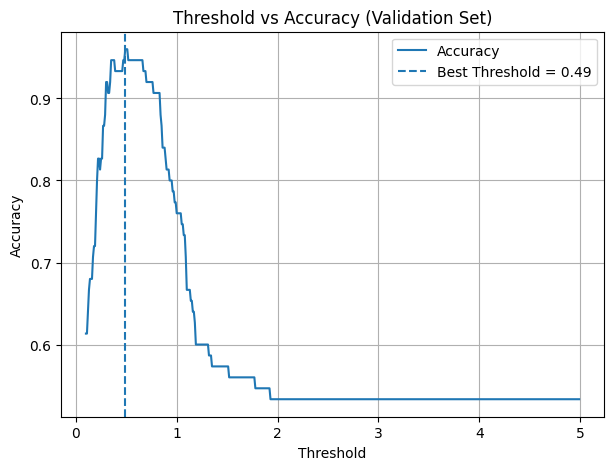

In [ ]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

thresholds = np.arange(0.1, 5.0, 0.01)
accuracies = []

for t in thresholds:
    preds = (val_distances > t).astype(int)
    accuracies.append(accuracy_score(val_labels, preds))

plt.figure(figsize=(7,5))
plt.plot(thresholds, accuracies, label="Accuracy")
plt.axvline(best_threshold, linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Threshold vs Accuracy (Validation Set)")
plt.legend()
plt.grid()
plt.show()


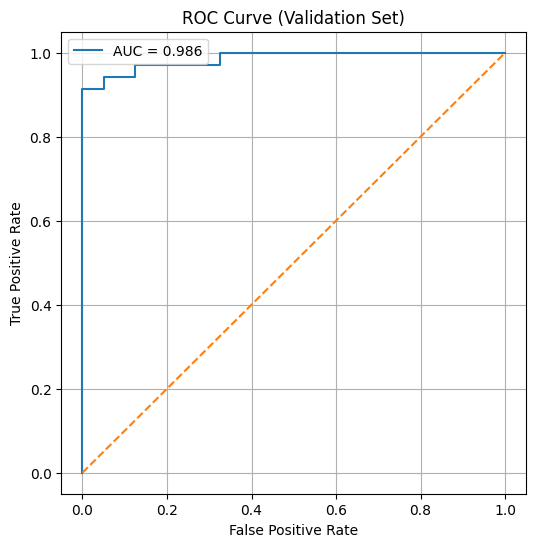

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, roc_thresholds = roc_curve(val_labels, val_distances)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation Set)")
plt.legend()
plt.grid()
plt.show()


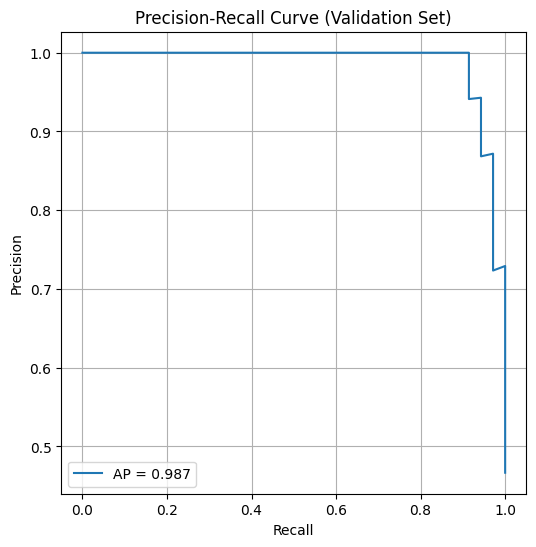

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(val_labels, val_distances)
ap = average_precision_score(val_labels, val_distances)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation Set)")
plt.legend()
plt.grid()
plt.show()


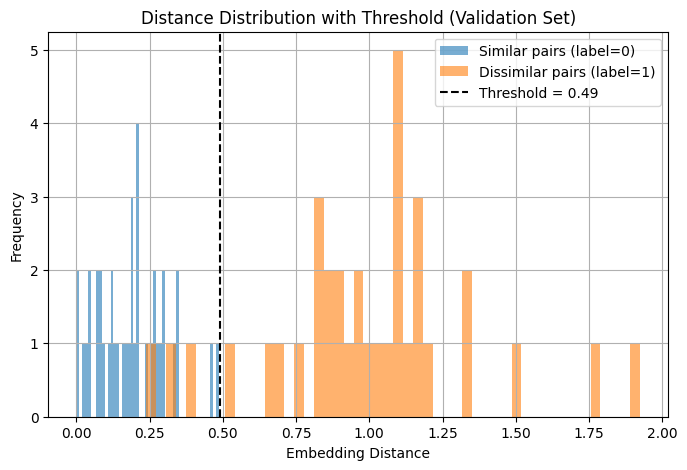

In [ ]:
same_dist = val_distances[val_labels == 0]
diff_dist = val_distances[val_labels == 1]

plt.figure(figsize=(8,5))
plt.hist(same_dist, bins=50, alpha=0.6, label="Similar pairs (label=0)")
plt.hist(diff_dist, bins=50, alpha=0.6, label="Dissimilar pairs (label=1)")

plt.axvline(best_threshold, linestyle='--', color='black',
            label=f"Threshold = {best_threshold:.2f}")

plt.xlabel("Embedding Distance")
plt.ylabel("Frequency")
plt.title("Distance Distribution with Threshold (Validation Set)")
plt.legend()
plt.grid()
plt.show()


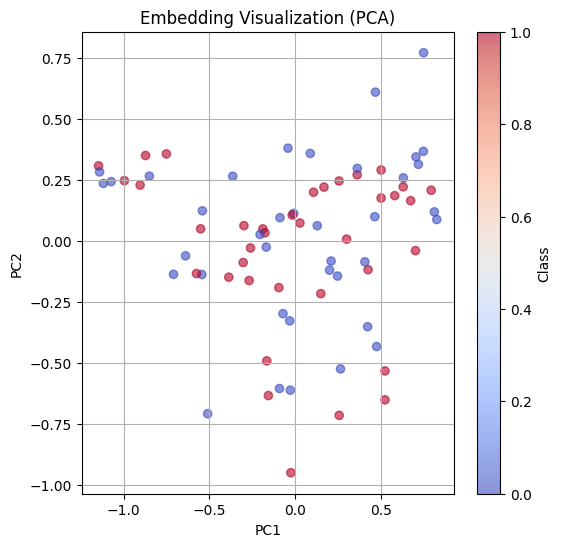

In [ ]:
from sklearn.decomposition import PCA

# embeddingleri çıkar
embeddings = []
labels = []

model.eval()
with torch.no_grad():
    for img1, img2, label in val_loader:
        img1 = img1.to(device)
        out1 = model.forward_once(img1)

        embeddings.append(out1.cpu().numpy())
        labels.append(label.numpy())

embeddings = np.vstack(embeddings)
labels = np.hstack(labels)

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(6,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels, cmap="coolwarm", alpha=0.6)
plt.title("Embedding Visualization (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class")
plt.grid()
plt.show()
